# MuTap AEC vs. WebRTC AEC3 and Speex MDF

Plots the committed comparison results. Prose, methodology and the full
reading guide live in [`docs/aec-comparison.md`](../docs/aec-comparison.md).

Two directions:
1. **Their algorithms through our tests** — `bench/compare/results/baseline.json`
2. **Our algorithm through their test (AECMOS)** — `bench/compare/results/aecmos.json`

Needs only `numpy` and `matplotlib`; it reads the JSON the harness already wrote.

In [1]:
import json, os
import numpy as np
import matplotlib.pyplot as plt

root = os.path.join(os.path.dirname(os.getcwd()), 'bench', 'compare', 'results') \
       if os.path.basename(os.getcwd()) == 'notebooks' else 'bench/compare/results'
base = json.load(open(os.path.join(root, 'baseline.json')))['results']
print(f"{len(base)} rows:", sorted({r['subject'] for r in base}))

10 rows: ['mutap', 'mutap-f32', 'mutap-linear', 'speex', 'webrtc']


## Direction 1 — echo depth, convergence, near-end preservation, cost

One panel per rate. Bars are grouped by subject.

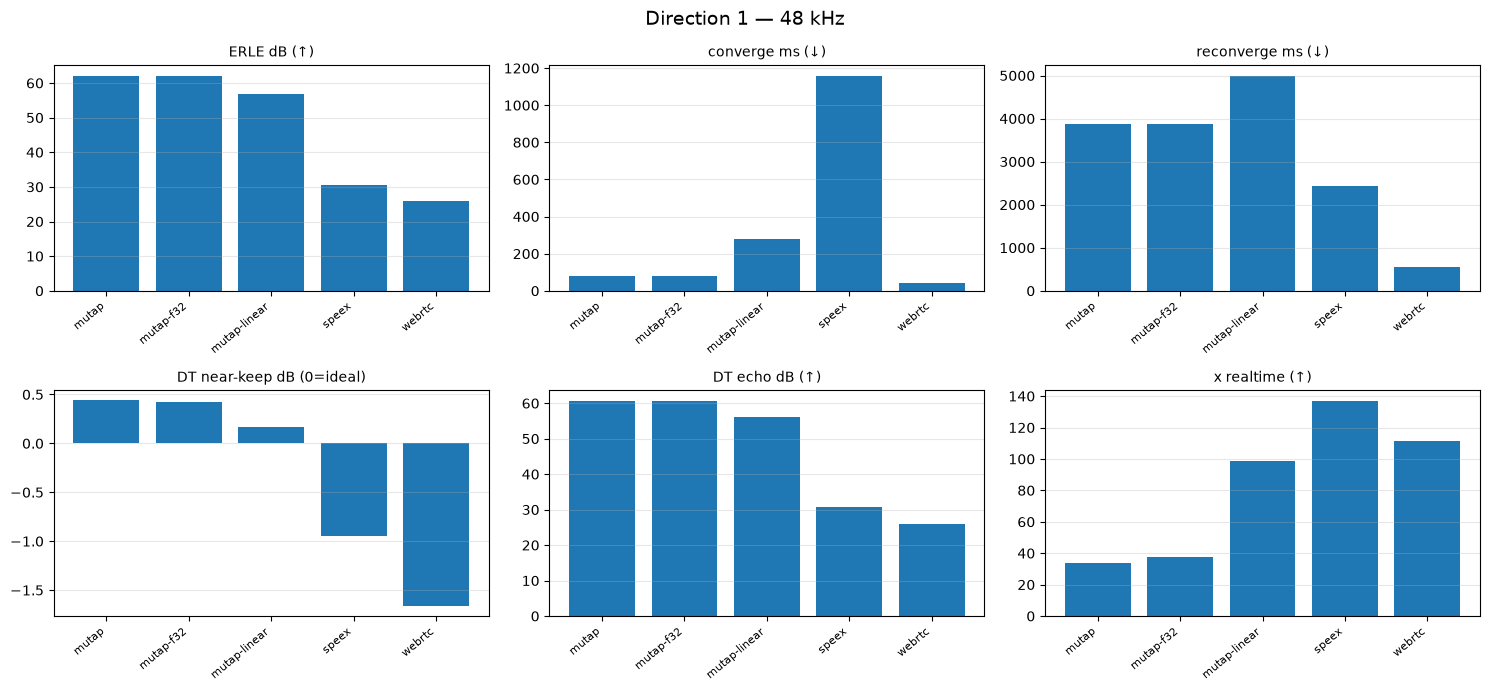

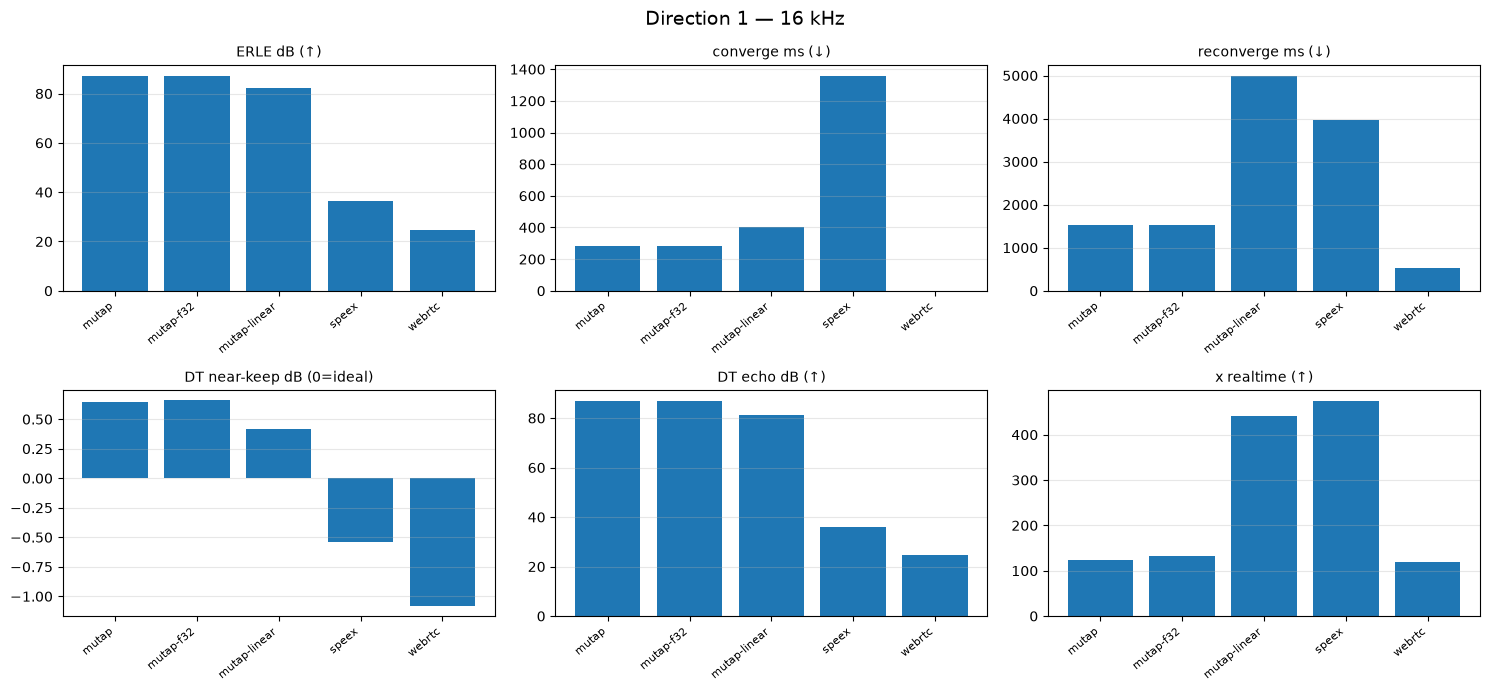

In [2]:
def rows_at(fs): return [r for r in base if r['fs']==fs]
metrics = [('erle_db','ERLE dB (↑)'),('converge_ms','converge ms (↓)'),
           ('reconverge_ms','reconverge ms (↓)'),('dt_near_keep_db','DT near-keep dB (0=ideal)'),
           ('dt_echo_supp_db','DT echo dB (↑)'),('x_realtime','x realtime (↑)')]
for fs in [48000,16000]:
    rs = rows_at(fs); subs=[r['subject'] for r in rs]
    fig,axs=plt.subplots(2,3,figsize=(15,7)); fig.suptitle(f'Direction 1 — {fs//1000} kHz',fontsize=14)
    for ax,(k,lab) in zip(axs.flat,metrics):
        vals=[min(r[k],5000) if 'ms' in k else r[k] for r in rs]
        ax.bar(range(len(subs)),vals,color='tab:blue'); ax.set_title(lab,fontsize=10)
        ax.set_xticks(range(len(subs))); ax.set_xticklabels(subs,rotation=40,ha='right',fontsize=8)
        ax.grid(axis='y',alpha=0.3)
    plt.tight_layout(); plt.show()

### The trade in one plot: ERLE depth vs. convergence speed
MuTap buys steady-state depth; AEC3 buys convergence/tracking speed.

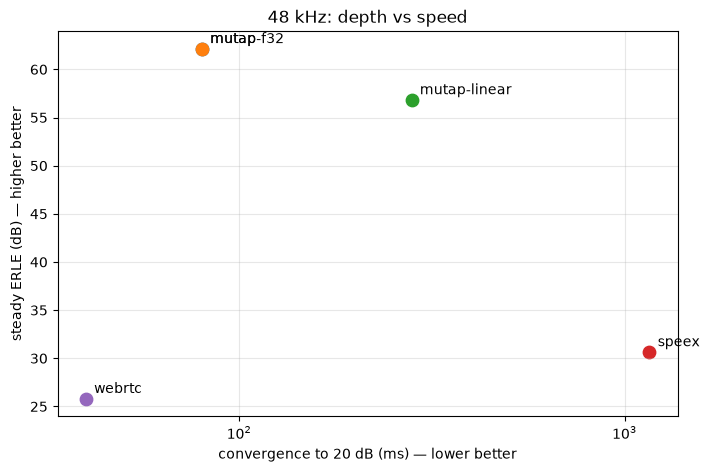

In [3]:
rs=rows_at(48000)
fig,ax=plt.subplots(figsize=(8,5))
for r in rs:
    ax.scatter(r['converge_ms'],r['erle_db'],s=80)
    ax.annotate(r['subject'],(r['converge_ms'],r['erle_db']),xytext=(6,4),textcoords='offset points')
ax.set_xlabel('convergence to 20 dB (ms) — lower better')
ax.set_ylabel('steady ERLE (dB) — higher better')
ax.set_xscale('symlog'); ax.set_title('48 kHz: depth vs speed'); ax.grid(alpha=0.3); plt.show()

## Direction 2 — AECMOS (their metric), on real speech

Every subject's cleaned output scored by the ICASSP AEC-Challenge AECMOS
predictor: echo MOS (higher = less audible echo) and degradation MOS
(higher = better near-end quality). Real speech (distinct speakers for
far/near) through a simulated room, so absolutes are calibrated. The
Microsoft blind clips themselves are Git-LFS-gated in this environment;
`--real-dir` points the same driver at them when available. Enh is
cross-correlation-aligned to the mic per subject so latency is not a
confound.

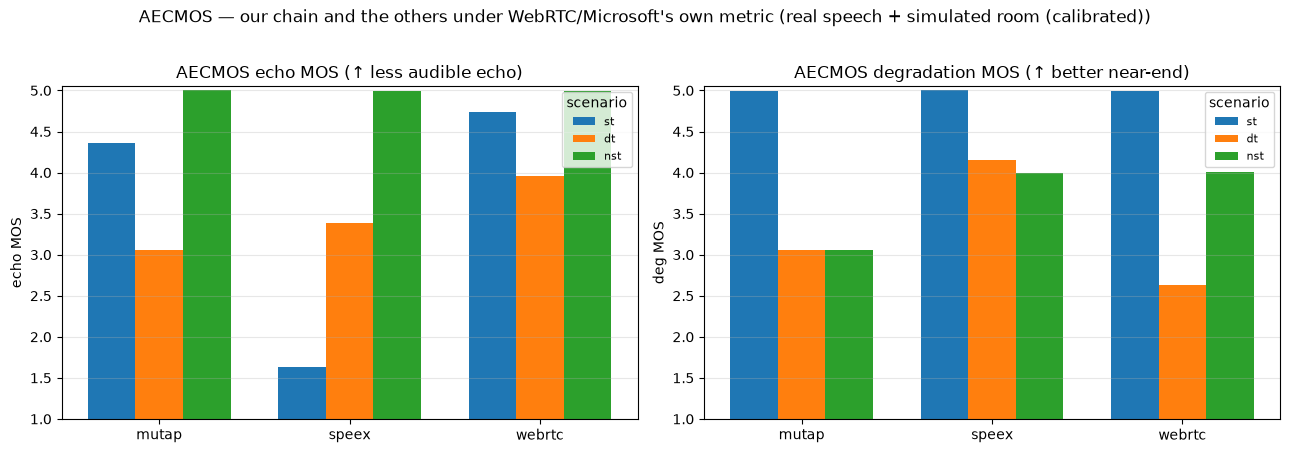

In [4]:
ap=os.path.join(root,'aecmos.json')
if os.path.exists(ap):
    am=json.load(open(ap)); rows=am['rows']
    subs=sorted({r['subject'] for r in rows}); scen=['st','dt','nst']
    cal = am.get('calibrated', not am.get('synthetic', True))
    src = {'real-corpus':'real AEC-Challenge corpus','real-speech':'real speech + simulated room (calibrated)','synthetic':'synthetic — relative only'}.get(am.get('kind'), 'calibrated' if cal else 'synthetic — relative only')
    fig,(axe,axd)=plt.subplots(1,2,figsize=(13,4.4)); w=0.25
    for i,s in enumerate(scen):
        axe.bar(np.arange(len(subs))+i*w,[next((r['echo_mos'] for r in rows if r['subject']==u and r['scenario']==s),0) for u in subs],w,label=s)
        axd.bar(np.arange(len(subs))+i*w,[next((r['deg_mos'] for r in rows if r['subject']==u and r['scenario']==s),0) for u in subs],w,label=s)
    for ax,ttl,yl in ((axe,'AECMOS echo MOS (↑ less audible echo)','echo MOS'),(axd,'AECMOS degradation MOS (↑ better near-end)','deg MOS')):
        ax.set_xticks(np.arange(len(subs))+w); ax.set_xticklabels(subs); ax.set_ylabel(yl); ax.set_ylim(1,5.05)
        ax.set_title(ttl); ax.legend(title='scenario',fontsize=8); ax.grid(axis='y',alpha=0.3)
    fig.suptitle(f'AECMOS — our chain and the others under WebRTC/Microsoft\'s own metric ({src})', y=1.02)
    plt.tight_layout(); plt.show()
else:
    print('run tools/compare/aecmos_eval.py first')

## Nonlinear loudspeaker — where AEC3 earns its reputation

Every path so far is linear (room convolution). Real loudspeakers distort;
a Hammerstein model (a memoryless scaled-error-function nonlinearity, then
the room) exercises the regime a linear canceller structurally cannot win.
Left: ERLE (linear cancellation depth, `--nl-sweep`). Right: AECMOS
perceived echo on real speech (`aecmos_eval.py --nl-sweep`).

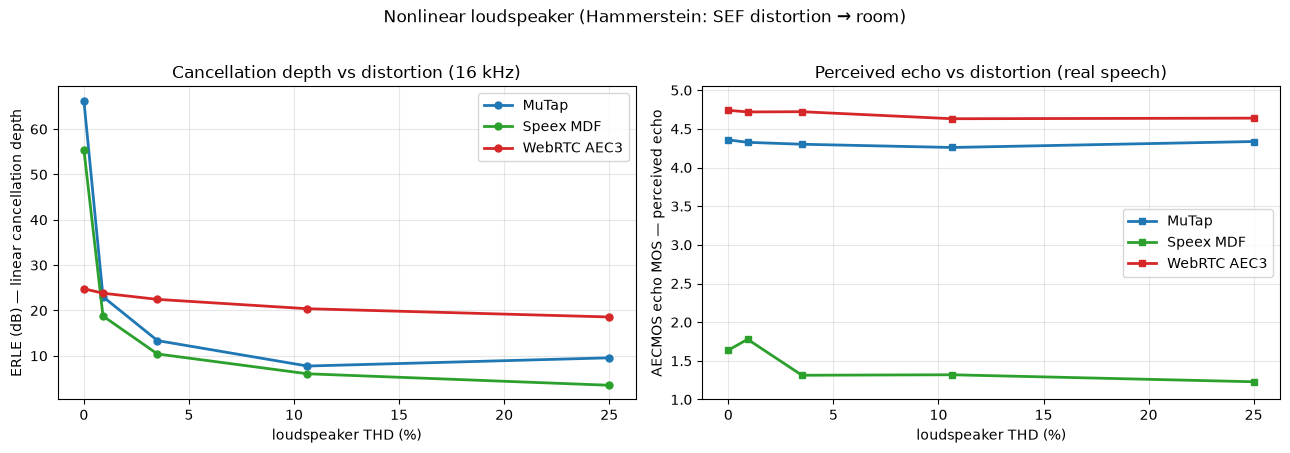

In [5]:
COL={'mutap':'#1f77b4','webrtc':'#d62728','speex':'#2ca02c'}
LBL={'mutap':'MuTap','webrtc':'WebRTC AEC3','speex':'Speex MDF'}
erle=json.load(open(os.path.join(root,'nl_sweep.json')))
amnl=json.load(open(os.path.join(root,'nl_aecmos.json')))
subs=list(erle['sweep'][0]['results'].keys())
thd=[r['thd_pct'] for r in erle['sweep']]
fig,(a1,a2)=plt.subplots(1,2,figsize=(13,4.4))
for s in subs:
    a1.plot(thd,[r['results'].get(s) for r in erle['sweep']],'o-',color=COL.get(s),label=LBL.get(s,s),lw=2,ms=5)
a1.set_xlabel('loudspeaker THD (%)'); a1.set_ylabel('ERLE (dB) — linear cancellation depth')
a1.set_title(f"Cancellation depth vs distortion ({erle['fs']//1000:.0f} kHz)"); a1.grid(alpha=0.3); a1.legend()
t2=[r['thd_pct'] for r in amnl['sweep']]
for s in subs:
    a2.plot(t2,[r['echo_mos'].get(s) for r in amnl['sweep']],'s-',color=COL.get(s),label=LBL.get(s,s),lw=2,ms=5)
a2.set_xlabel('loudspeaker THD (%)'); a2.set_ylabel('AECMOS echo MOS — perceived echo'); a2.set_ylim(1,5.05)
a2.set_title('Perceived echo vs distortion (real speech)'); a2.grid(alpha=0.3); a2.legend()
fig.suptitle('Nonlinear loudspeaker (Hammerstein: SEF distortion → room)',y=1.02)
plt.tight_layout(); plt.show()

**The most important reframing in the whole comparison.** MuTap's and
Speex's linear filters shed 40+ dB of ERLE the instant the speaker
distorts — the harmonics are not in their linear reference — and cross
WebRTC AEC3 below ~1% THD (a decent speaker at moderate volume). AEC3's
nonlinear-aware suppressor holds ~19–24 dB across the range. Perceptually
(right) the blow is softer for MuTap: its residual suppressor + comfort
noise mask much of the residual its linear filter leaves, so AECMOS echo
MOS barely moves — raw ERLE overstates the nonlinear vulnerability of a
chain that carries a suppressor. Speex, with no residual stage, stays low
(floored by the reverb tail). The linear-path dominance MuTap shows
everywhere else is real only on a linear path.